# 06 · The constrained twin
*From noisy biased tracers back to the cosmic web — and what survey depth buys you.*

The end-game is a simulation **constrained by data**. The minimal engine is the Wiener filter — the optimal linear estimator
$$\hat\delta(k)=\underbrace{\frac{bP(k)}{b^2P(k)+1/\bar n}}_{G(k)}\,\delta_g(k)$$
— plus **constrained realizations** (Hoffman–Ribak): the Wiener mean with statistically-correct small-scale power filled back in.

In [1]:
%matplotlib inline
import os, sys, json, time, sqlite3, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
plt.rcParams.update({'figure.dpi':115,'font.size':10.5,'axes.titlesize':11.5,
    'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white'})
C0,C1,C2,C3,C4 = '#3a6ea5','#d1495b','#3c8d53','#edae49','#7d5ba6'
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_REAL = EBOSS.exists() and DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
def moll(ax, ra, dec, **kw):
    lon = np.radians(((np.asarray(ra)+180)%360)-180)
    ax.scatter(lon, np.radians(dec), **kw)
print('real eBOSS+DESI available:', HAVE_REAL)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS+DESI available: True


## The filter itself
The Wiener gain G(k) for several tracer densities: deeper surveys (higher n̄) trust the data to smaller scales.

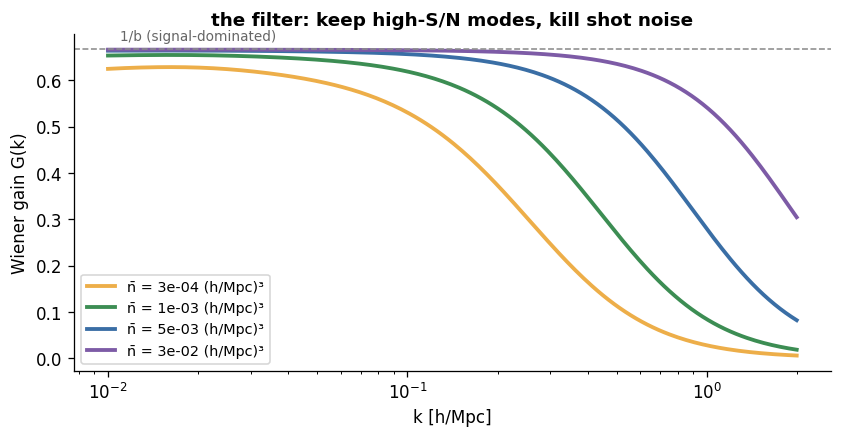

In [2]:
from oneuniverse.simulation.linear.power_spectrum import linear_power
kk=np.logspace(-2,0.3,250); P=linear_power(kk,COSMO,z=0.0); bias=1.5
fig,ax=plt.subplots(figsize=(8.5,3.8))
for nb,c in zip([3e-4,1e-3,5e-3,3e-2],[C3,C2,C0,C4]):
    G=bias*P/(bias**2*P+1/nb)
    ax.semilogx(kk,G,lw=2.4,color=c,label=f'n̄ = {nb:.0e} (h/Mpc)³')
ax.axhline(1/bias,color='.55',ls='--',lw=1); ax.text(.011,1/bias+.02,'1/b (signal-dominated)',fontsize=8.5,color='.4')
ax.set_xlabel('k [h/Mpc]'); ax.set_ylabel('Wiener gain G(k)')
ax.set_title('the filter: keep high-S/N modes, kill shot noise'); ax.legend(fontsize=9)
plt.show()

## Truth → tracers → Wiener mean → constrained realization
Linear-bias Poisson tracers (shot-noise-limited — the regime the linear filter is optimal for). The Wiener mean is smooth where data is uninformative; the constrained realization restores realistic small-scale texture while honouring the data.

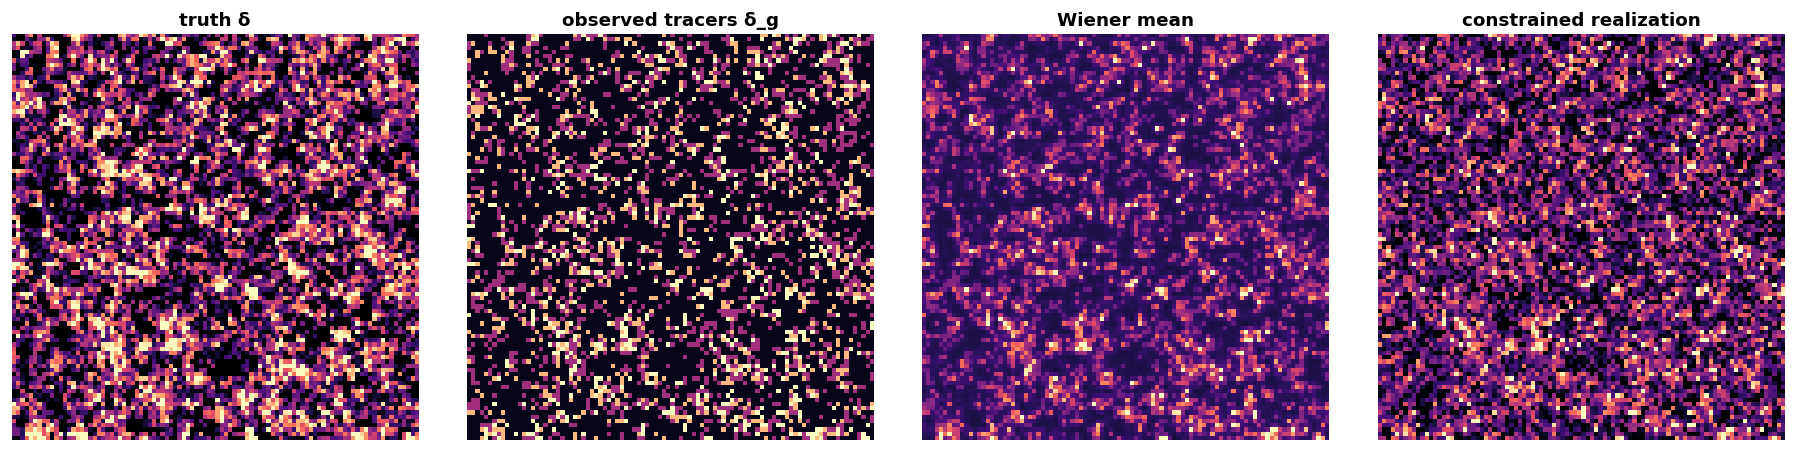

variance:  truth 3.17 | Wiener 0.64 (over-smooth, by design) | constrained 1.38 (restored)


In [3]:
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.twin.mock_observe import mock_tracer_field
from oneuniverse.twin.wiener import wiener_reconstruct
from oneuniverse.twin.constrained import constrained_realization
from oneuniverse.twin.verify import cross_correlation
BOX,N=400.0,96; bias=1.5; nbar=5e-3
truth=generate_density_field(COSMO,box_size=BOX,n_grid=N,z=0.0,seed=5)
obs=mock_tracer_field(truth,box_size=BOX,nbar=nbar,bias=bias,seed=6,model='clip')
rec=wiener_reconstruct(obs['delta_g'],COSMO,box_size=BOX,nbar=nbar,bias=bias,z=0.0)
cr=constrained_realization(obs['delta_g'],COSMO,box_size=BOX,nbar=nbar,bias=bias,z=0.0,seed=11)
sl=N//2
fig,ax=plt.subplots(1,4,figsize=(16,3.9))
for a,f,t in ((ax[0],truth,'truth δ'),(ax[1],obs['delta_g'],'observed tracers δ_g'),
              (ax[2],rec,'Wiener mean'),(ax[3],cr,'constrained realization')):
    im=a.imshow(f[:,:,sl].T,origin='lower',cmap='magma',vmin=-1.2,vmax=3)
    a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()
print('variance:  truth %.2f | Wiener %.2f (over-smooth, by design) | constrained %.2f (restored)'
      %(truth.var(),rec.var(),cr.var()))

## Fidelity, quantified — and the depth–fidelity law
r(k) between reconstruction and truth for a range of survey depths; the reconstruction scale $k_{1/2}$ (where r = 0.5) tightens monotonically with n̄.

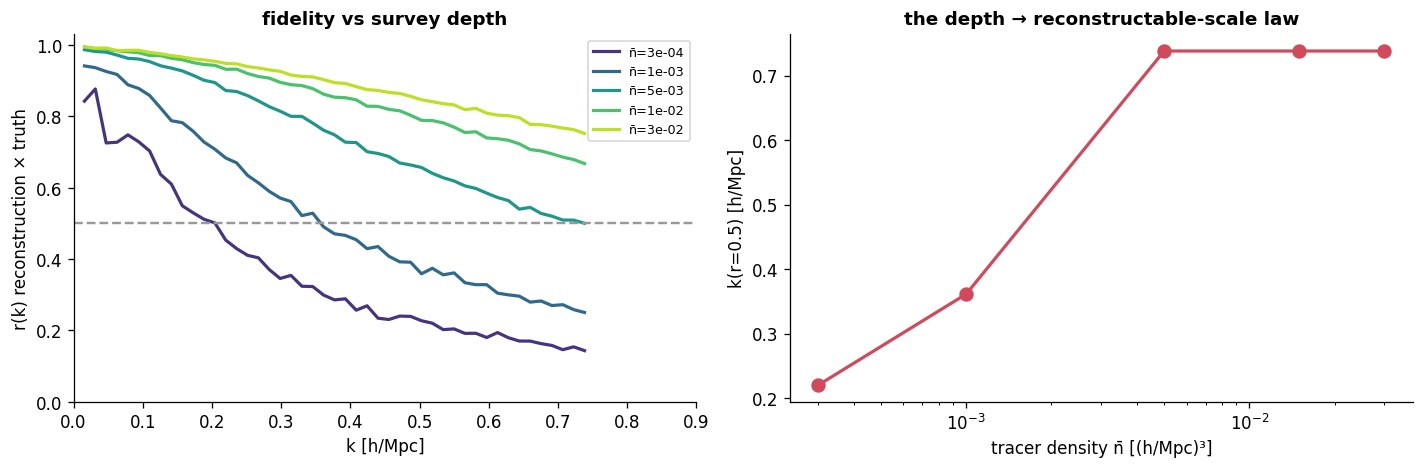

k_half: 0.22, 0.36, 0.74, 0.74, 0.74


In [4]:
def khalf_for(nb,seed=10):
    o=mock_tracer_field(truth,box_size=BOX,nbar=nb,bias=bias,seed=seed,model='clip')
    rr=wiener_reconstruct(o['delta_g'],COSMO,box_size=BOX,nbar=nb,bias=bias,z=0.0)
    kk2,r2=cross_correlation(rr,truth,box_size=BOX)
    bel=np.where(r2<0.5)[0]
    return (kk2[bel[0]] if len(bel) else kk2[-1]), kk2, r2
nbars=[3e-4,1e-3,5e-3,1.5e-2,3e-2]
res=[khalf_for(nb) for nb in nbars]
fig,ax=plt.subplots(1,2,figsize=(12.5,4.2))
cmap=plt.cm.viridis(np.linspace(.15,.9,len(nbars)))
for (nb,(kh,kk2,r2)),c in zip(zip(nbars,res),cmap):
    ax[0].plot(kk2,r2,lw=2,color=c,label=f'n̄={nb:.0e}')
ax[0].axhline(.5,color='.6',ls='--'); ax[0].set_xlim(0,0.9); ax[0].set_ylim(0,1.03)
ax[0].set_xlabel('k [h/Mpc]'); ax[0].set_ylabel('r(k) reconstruction × truth')
ax[0].legend(fontsize=8); ax[0].set_title('fidelity vs survey depth')
ax[1].semilogx(nbars,[kh for kh,_,_ in res],'o-',color=C1,lw=2,ms=8)
ax[1].set_xlabel('tracer density n̄ [(h/Mpc)³]'); ax[1].set_ylabel('k(r=0.5) [h/Mpc]')
ax[1].set_title('the depth → reconstructable-scale law')
plt.tight_layout(); plt.show()
print('k_half:', ', '.join('%.2f'%kh for kh,_,_ in res))

**What this showed.** The exact filter the package applies, the full chain truth→observation→reconstruction→constrained realization on a controlled mock (where the answer is known), and the quantitative law tying survey depth to the smallest reconstructable scale — the trade-off any constrained-simulation programme lives on. The Gaussian/linear engine is the MVP; the architecture (engines, store boundary, orchestration) is the part built for the real thing.